In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

df = pd.read_csv("Superstore-Sales.csv", encoding="latin-1")
print(df.columns.tolist()) #list all column names
print(df["Product Category"].value_counts()) #count rows per Category


['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date']
Product Category
Office Supplies    4610
Technology         2065
Furniture          1724
Name: count, dtype: int64


In [39]:
#Ttotal sales by region
by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(by_region)

Region
West                     3.597549e+06
Ontario                  3.063212e+06
Prarie                   2.837305e+06
Atlantic                 2.014248e+06
Quebec                   1.510195e+06
Yukon                    9.758674e+05
Northwest Territories    8.008473e+05
Nunavut                  1.163765e+05
Name: Sales, dtype: float64


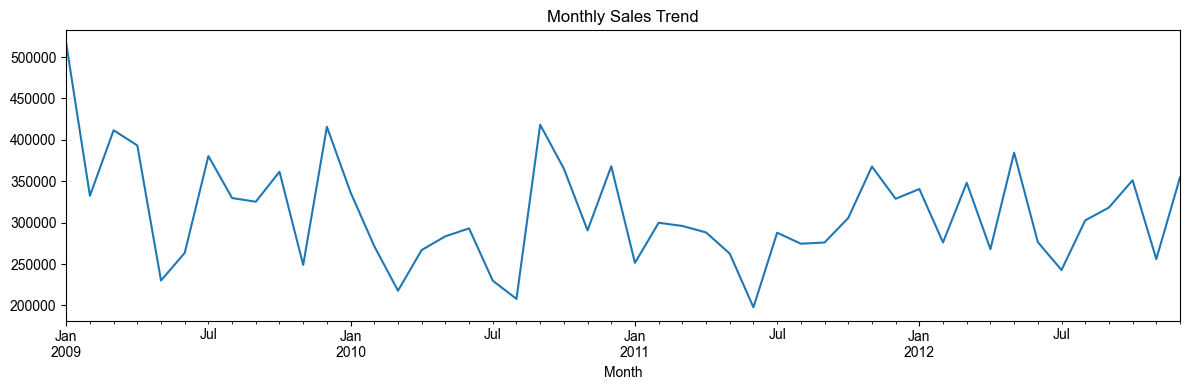

In [40]:
#Monthly trend
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.to_period("M")
monthly = df.groupby("Month")["Sales"].sum()
monthly.plot(title="Monthly Sales Trend", figsize=(12, 4))
plt.tight_layout()
plt.show()

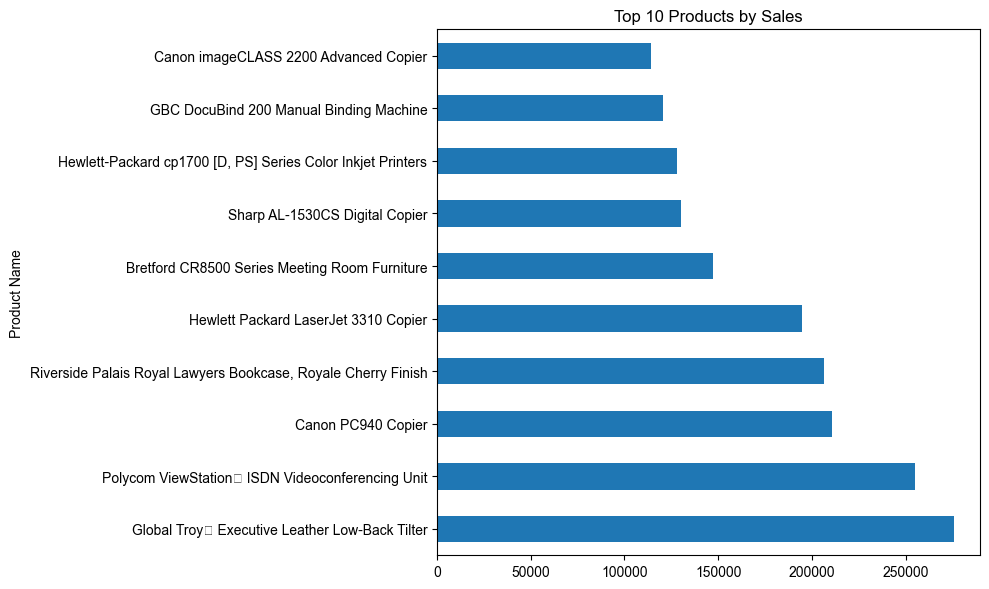

In [41]:
top10 = df.groupby("Product Name")["Sales"].sum().nlargest(10)
top10.plot(kind="barh", title="Top 10 Products by Sales", figsize=(10, 6))
plt.tight_layout()
plt.show()
